In [76]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


In [77]:
# configaration 
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid') 

In [78]:
df=pd.read_csv(r'C:\Users\Dilsh\Desktop\Machin_Learning\Data_sets\heart_desease.csv')

In [79]:
df.shape

(630000, 15)

In [80]:
df.head()   

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,Presence


In [81]:
#id column is not needed for analysis, so we can drop it
df.drop('id',axis=1,inplace=True)

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  str    
dtypes: float64(1), 

In [83]:
df.isnull().sum()   

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
print(df['Heart Disease'].value_counts(normalize=True)*100)

Heart Disease
Absence    55.166
Presence   44.834
Name: proportion, dtype: float64


In [86]:
#imbalence ratio
n_fraud=(df['Heart Disease']==1).sum()
n_nonfraud=(df['Heart Disease']==0).sum()
ratio=round(n_nonfraud/max(n_fraud,1),2)
print(ratio)

0.0


In [87]:
df['Heart Disease'].unique()

<ArrowStringArray>
['Presence', 'Absence']
Length: 2, dtype: str

In [88]:
#map Heart Disease column values Presence=1, Absence=0
df['Heart Disease']=df['Heart Disease'].map({'Presence':1,'Absence':0})

In [89]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,1


### Data Visualization

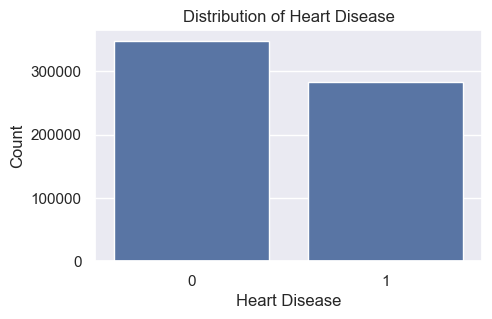

In [68]:
# visualization of target variable distribution
plt.figure(figsize=(5,3))
sns.countplot(x='Heart Disease',data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()


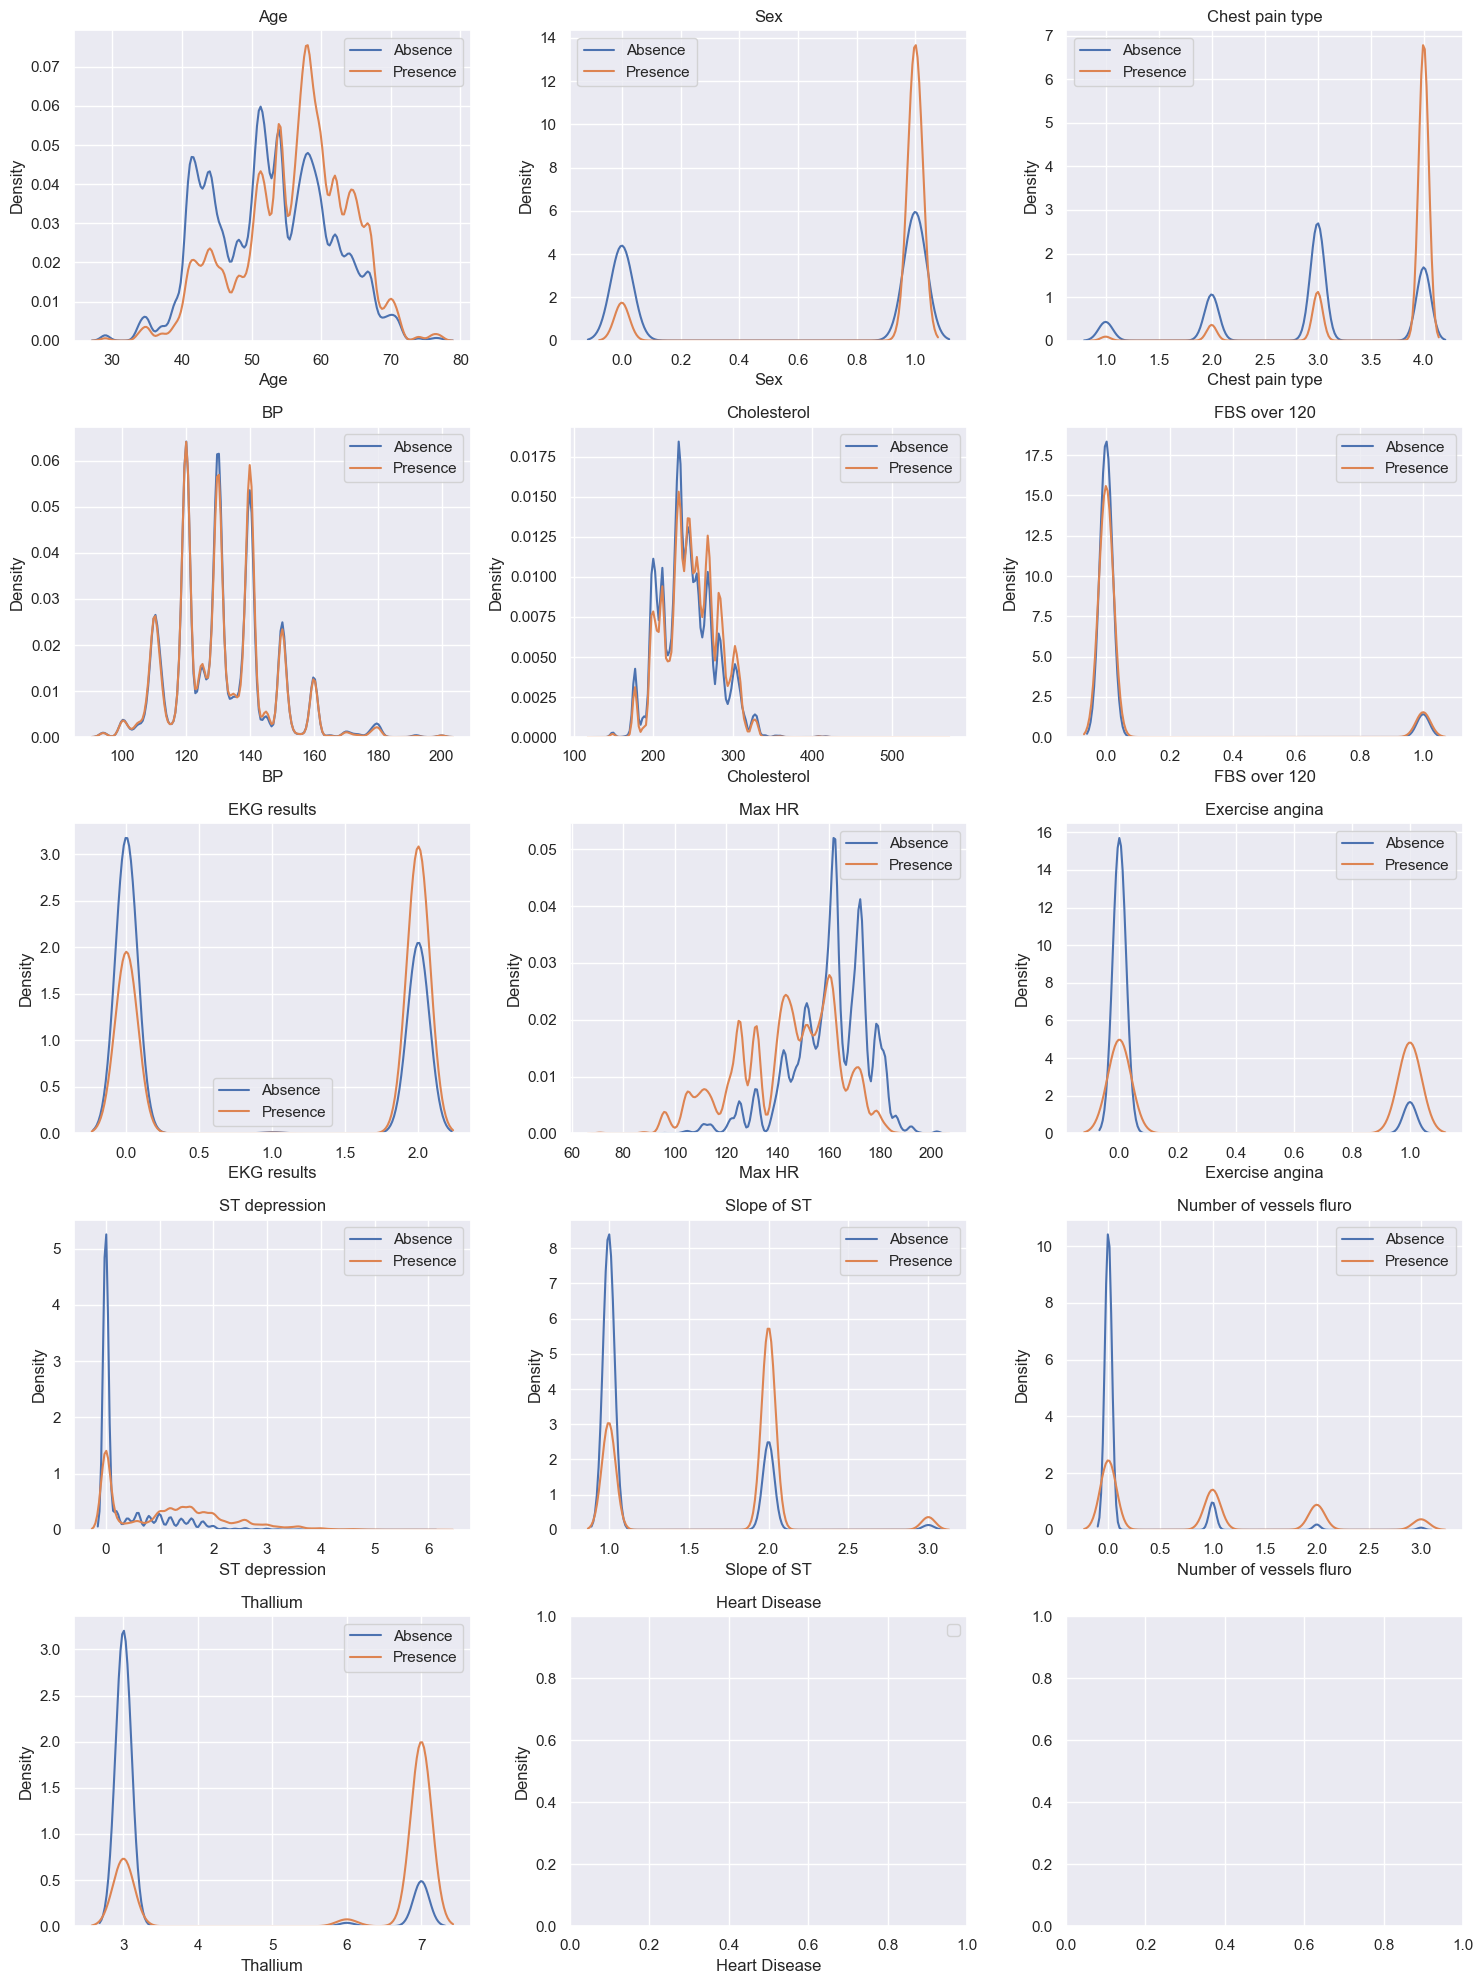

In [16]:
# crate kdeplot for all columns visual  have normal distribution or not
fig,axes=plt.subplots(5,3,figsize=(15,20))
axes=axes.flatten()

for i,col in enumerate(df.columns):
    sns.kdeplot(df[df['Heart Disease']==0][col],ax=axes[i], label='Absence')
    sns.kdeplot(df[df['Heart Disease']==1][col],ax=axes[i], label='Presence')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()
  



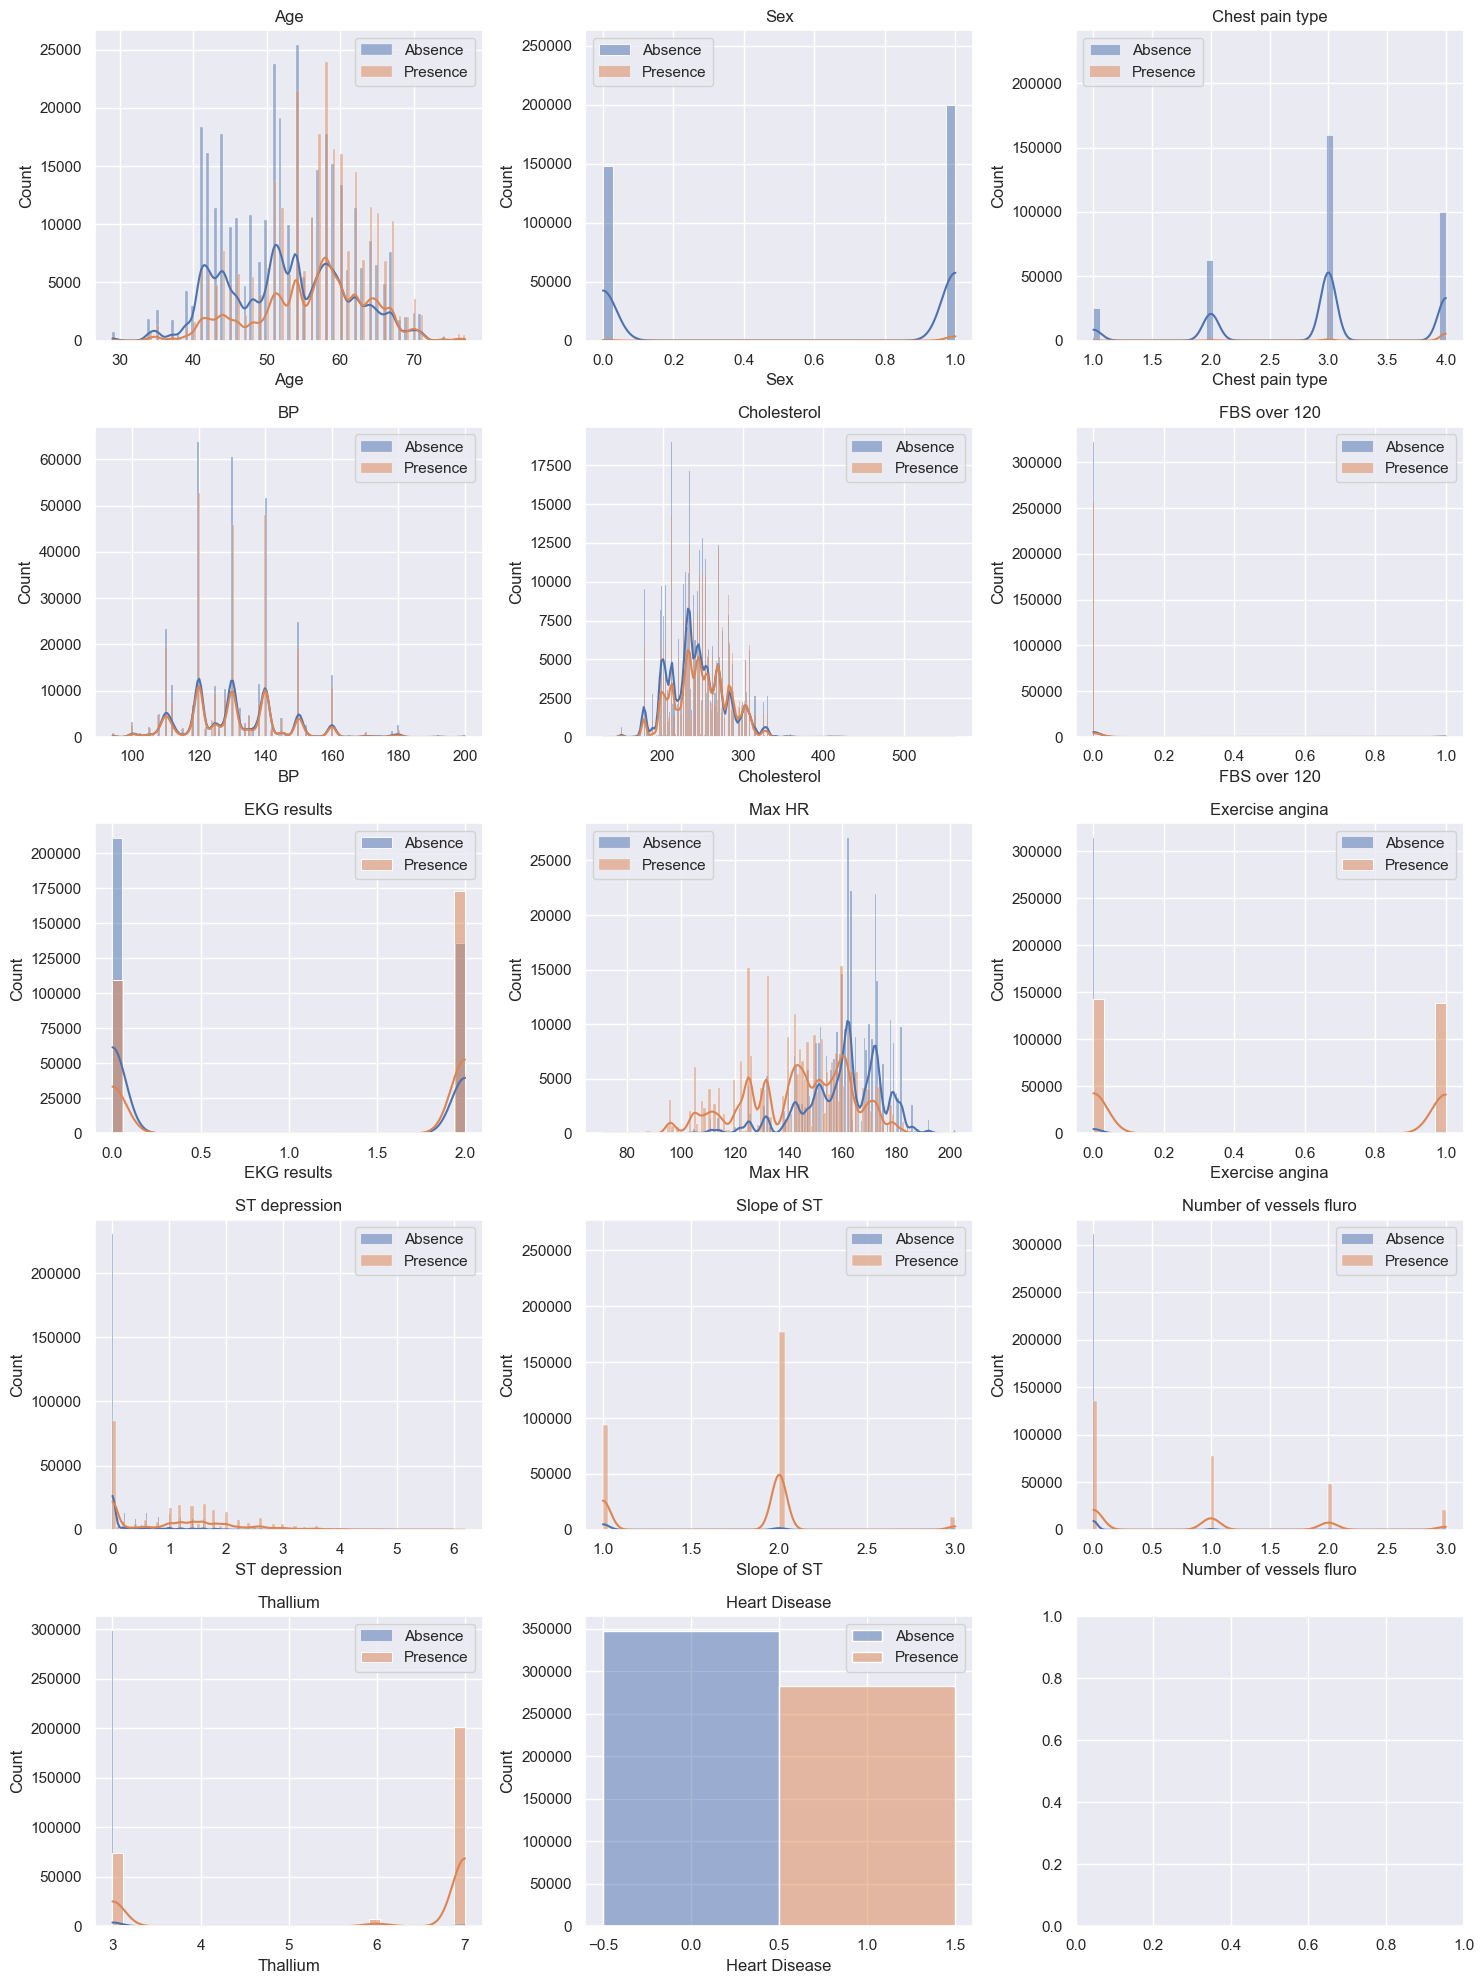

In [17]:
#histogram for all columns
fig,axes=plt.subplots(5,3,figsize=(15,20))
axes=axes.flatten()

for i,col in enumerate(df.columns):
    sns.histplot(df[df['Heart Disease']==0][col],ax=axes[i], label='Absence', kde=True)
    sns.histplot(df[df['Heart Disease']==1][col],ax=axes[i], label='Presence', kde=True)
    axes[i].set_title(col)
    axes[i].legend()        
plt.tight_layout()
plt.show()

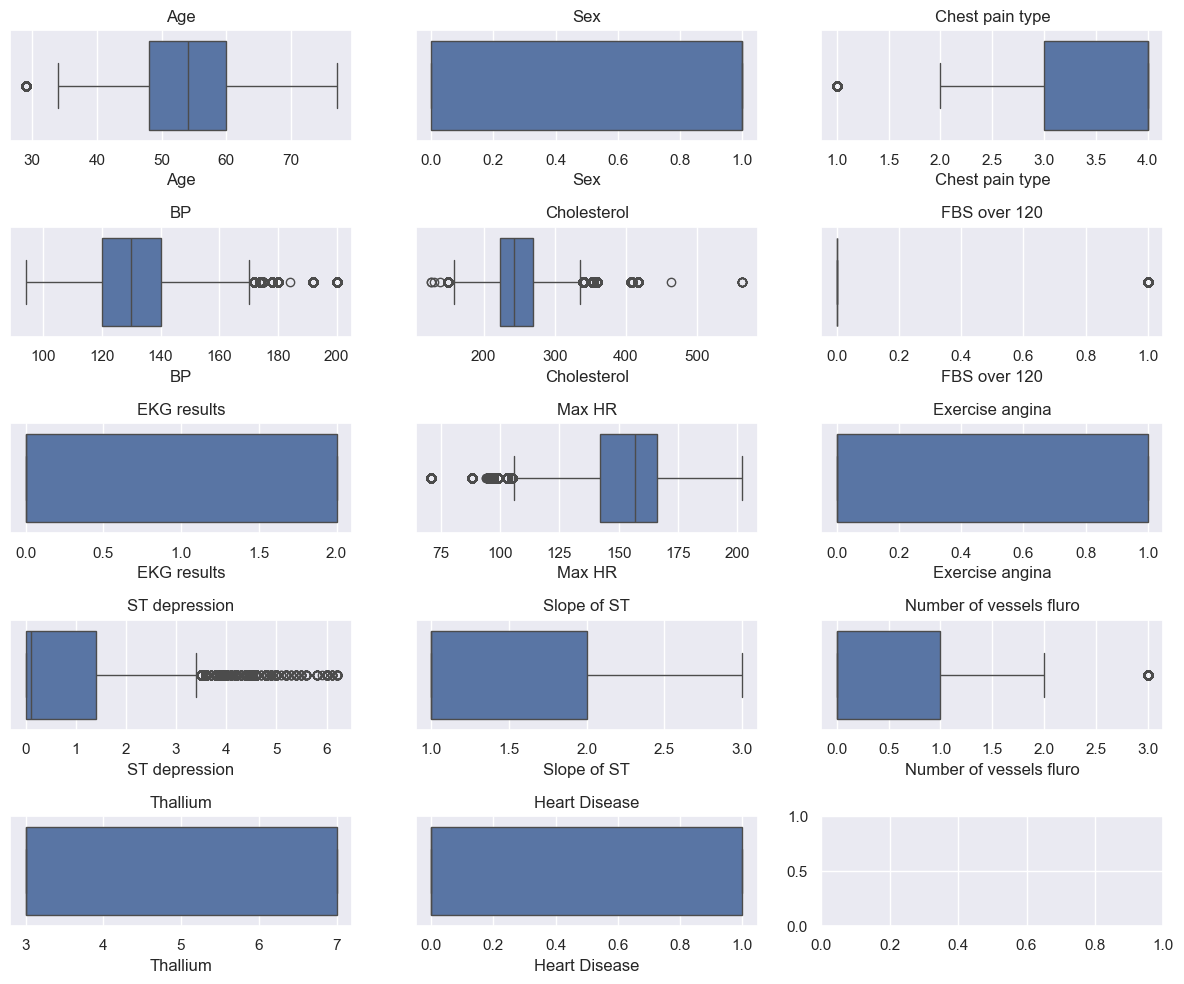

In [18]:
# box plot for all columns
fig, axes = plt.subplots(5, 3, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=col, data=df, ax=axes[i])  # horizontal
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [19]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [90]:
# remove rows with high cholesterol levels  >400
df['Cholesterol']=df['Cholesterol'].apply(lambda x: np.nan if x>400 else x)
print(df['Cholesterol'].describe())

#age
df['Age']=df['Age'].apply(lambda x: np.nan if x<10 or x>90 else x)
#check age range not using plot 
print(df['Age'].describe()  )

print(df.isnull().sum())

count   629660.000
mean       244.919
std         33.449
min        126.000
25%        222.000
50%        243.000
75%        269.000
max        360.000
Name: Cholesterol, dtype: float64
count   630000.000
mean        54.137
std          8.256
min         29.000
25%         48.000
50%         54.000
75%         60.000
max         77.000
Name: Age, dtype: float64
Age                          0
Sex                          0
Chest pain type              0
BP                           0
Cholesterol                340
FBS over 120                 0
EKG results                  0
Max HR                       0
Exercise angina              0
ST depression                0
Slope of ST                  0
Number of vessels fluro      0
Thallium                     0
Heart Disease                0
dtype: int64


In [91]:
df.dropna(inplace=True)

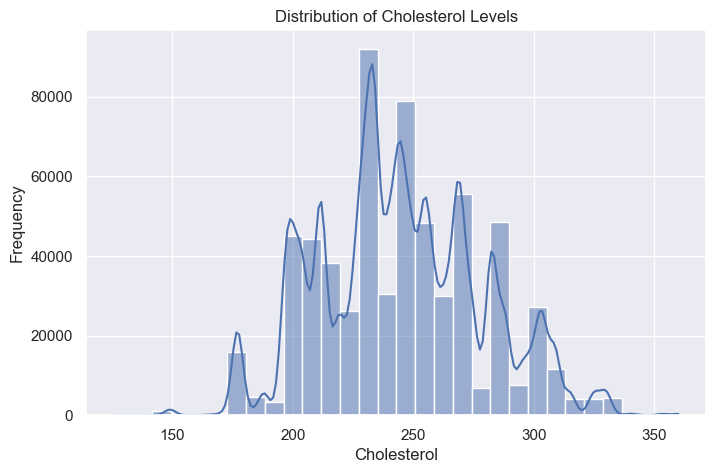

In [22]:
#check colestroll range
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol'], bins=30, kde=True)
plt.title('Distribution of Cholesterol Levels')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()


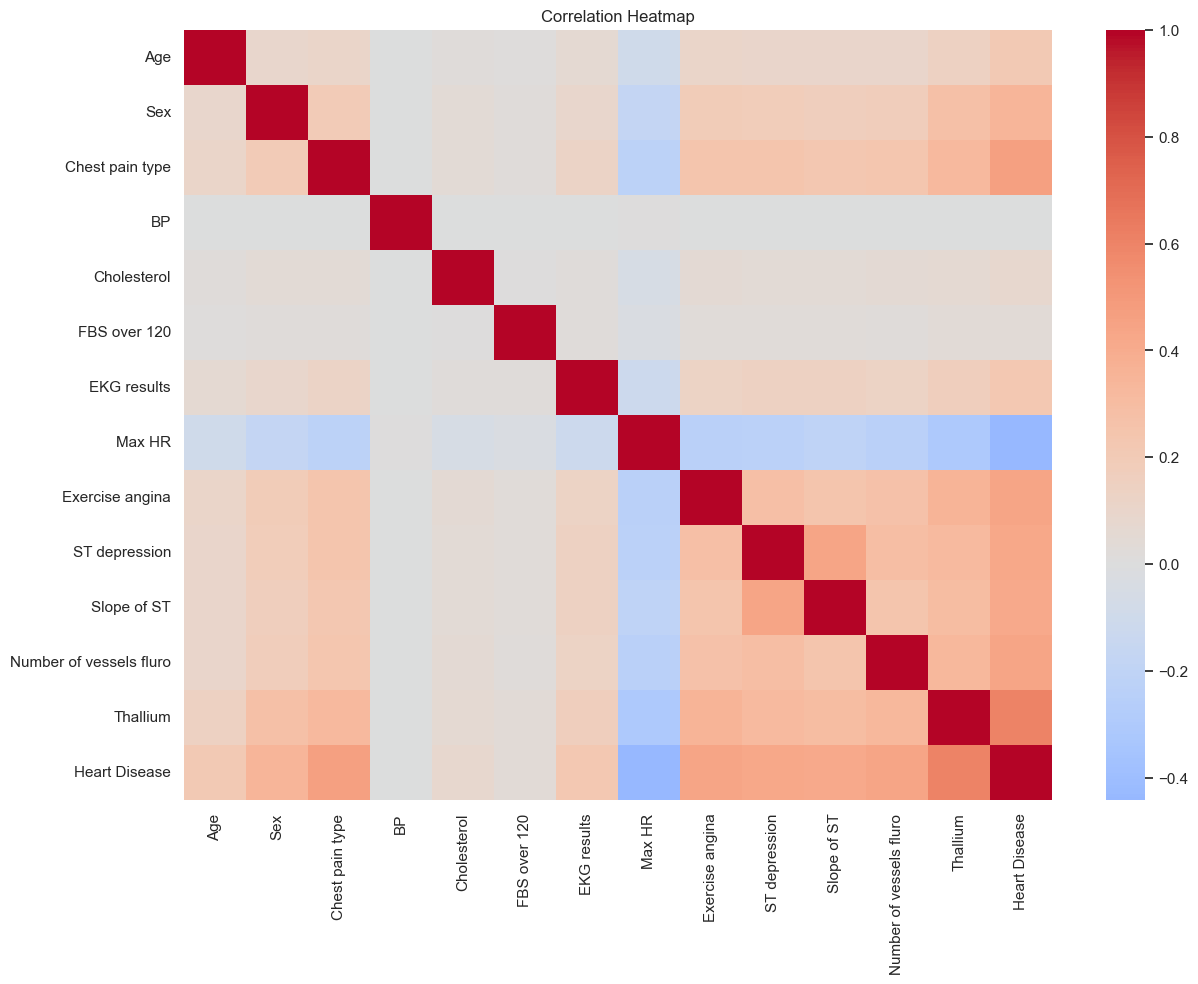

In [23]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()



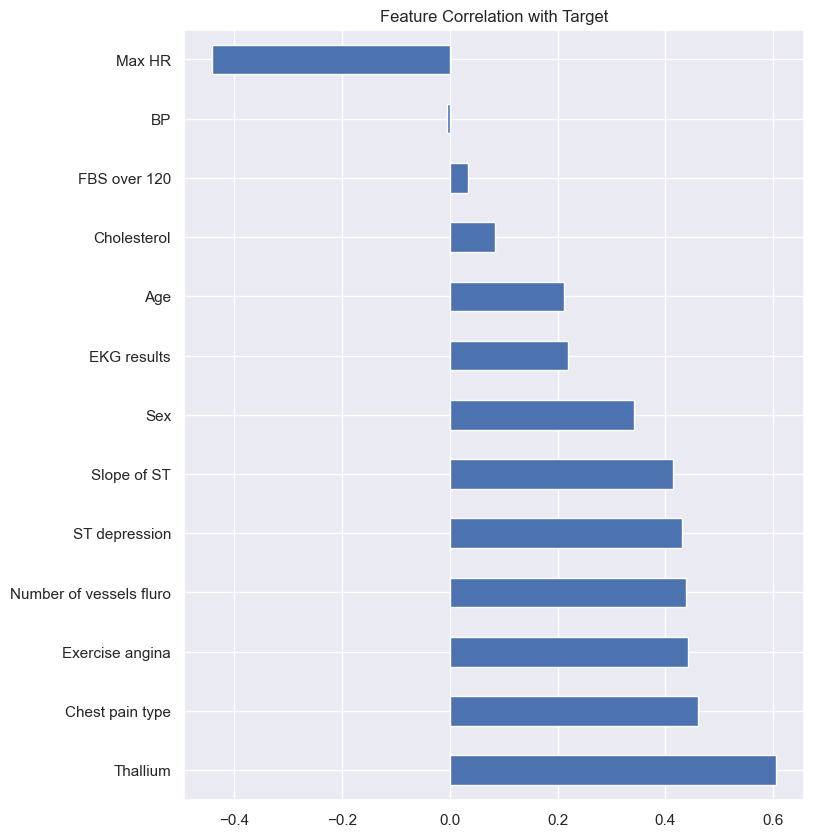

In [24]:
#CORRELATION WITH TARGET
corr_target = df.corr()['Heart Disease'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr_target.drop('Heart Disease').plot(kind='barh')
plt.title("Feature Correlation with Target")
plt.show()

In [92]:
#REMOVE HIGHLY CORRELATED FEATURES
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
print("\nHighly Correlated Columns:", drop_cols)


Highly Correlated Columns: []


### model building

In [93]:
x=df.drop('Heart Disease',axis=1)
y=df['Heart Disease']

In [94]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [47]:
#get all x_train,y_train,x_test,y_test using joblib
import joblib
joblib.dump(x_train,'x_train.pkl')
joblib.dump(y_train,'y_train.pkl')
joblib.dump(x_test,'x_test.pkl')
joblib.dump(y_test,'y_test.pkl')

['y_test.pkl']

In [48]:
 # scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [95]:
# pca for dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA()  

In [ ]:

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)


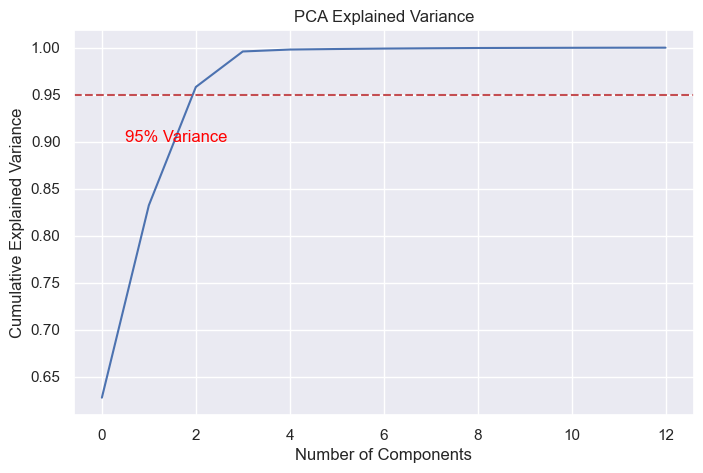

In [75]:
# cumulative variance ratio
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.text(0.5, 0.90, '95% Variance', color
='red', fontsize=12)
plt.show()

In [96]:
# 6 components 
pca = PCA(n_components=6)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)


In [97]:
joblib.dump(x_train_pca, "x_train_pca.pkl")
joblib.dump(x_test_pca, "x_test_pca.pkl")
joblib.dump(pca, "pca_model.pkl")

['pca_model.pkl']